# Wine Dataset - Predicting the quality of wine using different measuresments for it

**Question**: Can we predict the quality of wine based on different characteristics of it, such as pH, Sulphate content, density, etc.

**Background**: The quality of wine can be judged from it's sensory profile (taste, mouth feel, aroma), which can be affected by pH, cholride content, sulphate content, etc. 

**Hypothesis**: A classification model utilizing all the features in the data will yield a higher classification accuracy compared to a regression model optimized for the data.

## Dataset 
This dataset comes from the UCI machine learning repository. They include red and white vinho verde wine samples from Northern Portugal. Due to privacy concerns, only the physicochemical and sensory data is available. The data was collected via a computerized laboratory system called iLab during wine certification processes and later published by researcher Paulo Cortez. It was donated to the UCI machine learning repository on October 6th, 2009. There were 11 objective chemical tests per sample. These included precise measurements for features like volatile acidity, pH, density, and alcohol content. Every single wine sample was blind-tasted and graded by at least three independent wine experts. Experts scored the wine on an ordinal scale from 0 (very bad) to 10 (excellent). To eliminate personal bias, extreme anomalies, or individual scoring habits, the final quality label assigned to each row was the median score of those expert evaluations. This dataset has been collected ethically.

This dataset includes 12 featues (`volatile.acidity`, `citric.acid`, `residual.sugar`, `chlorides`, `free.sulfur.dioxide`, `total.sulfur.dioxide`, `density`, `pH`, `sulphates`, `alcohol`, `quality`), all of which are floats. There are 1599 observations. 

In [22]:
#Packages and retrieving the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import imblearn
filepath = "data/wineQualityReds.csv"
wineQuality = pd.read_csv(filepath)

In [2]:
#Cleaning the dataset and retrieving dataset characteristics
wineQuality=wineQuality.drop(wineQuality.columns[[0]], axis=1)
wineQuality.dropna
wineQuality.drop_duplicates
print(wineQuality.shape)
print(wineQuality.dtypes)
print(wineQuality.describe())
print(wineQuality.info())
wineQuality.head()

(1599, 12)
fixed.acidity           float64
volatile.acidity        float64
citric.acid             float64
residual.sugar          float64
chlorides               float64
free.sulfur.dioxide     float64
total.sulfur.dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
       fixed.acidity  volatile.acidity  citric.acid  residual.sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000   

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Single Variable Analysis

All the features include a large amount of outliers. Of the features available, only pH, density, and quality seem to be approximately normally distributed. The rest appear to be skewed right. The outliers were kept as disregarding them may under represent features and cause bias, which would misrepresent how well the model did regardless if it was a classification model or a regression model. The target variable was chosen to be `quality`. One important thing to note from the histograms is that `quality` has a class imbalance, where the amount of 3, 4, and 8 ratings are significantly less compared to the 5, 6, and 7 ratings

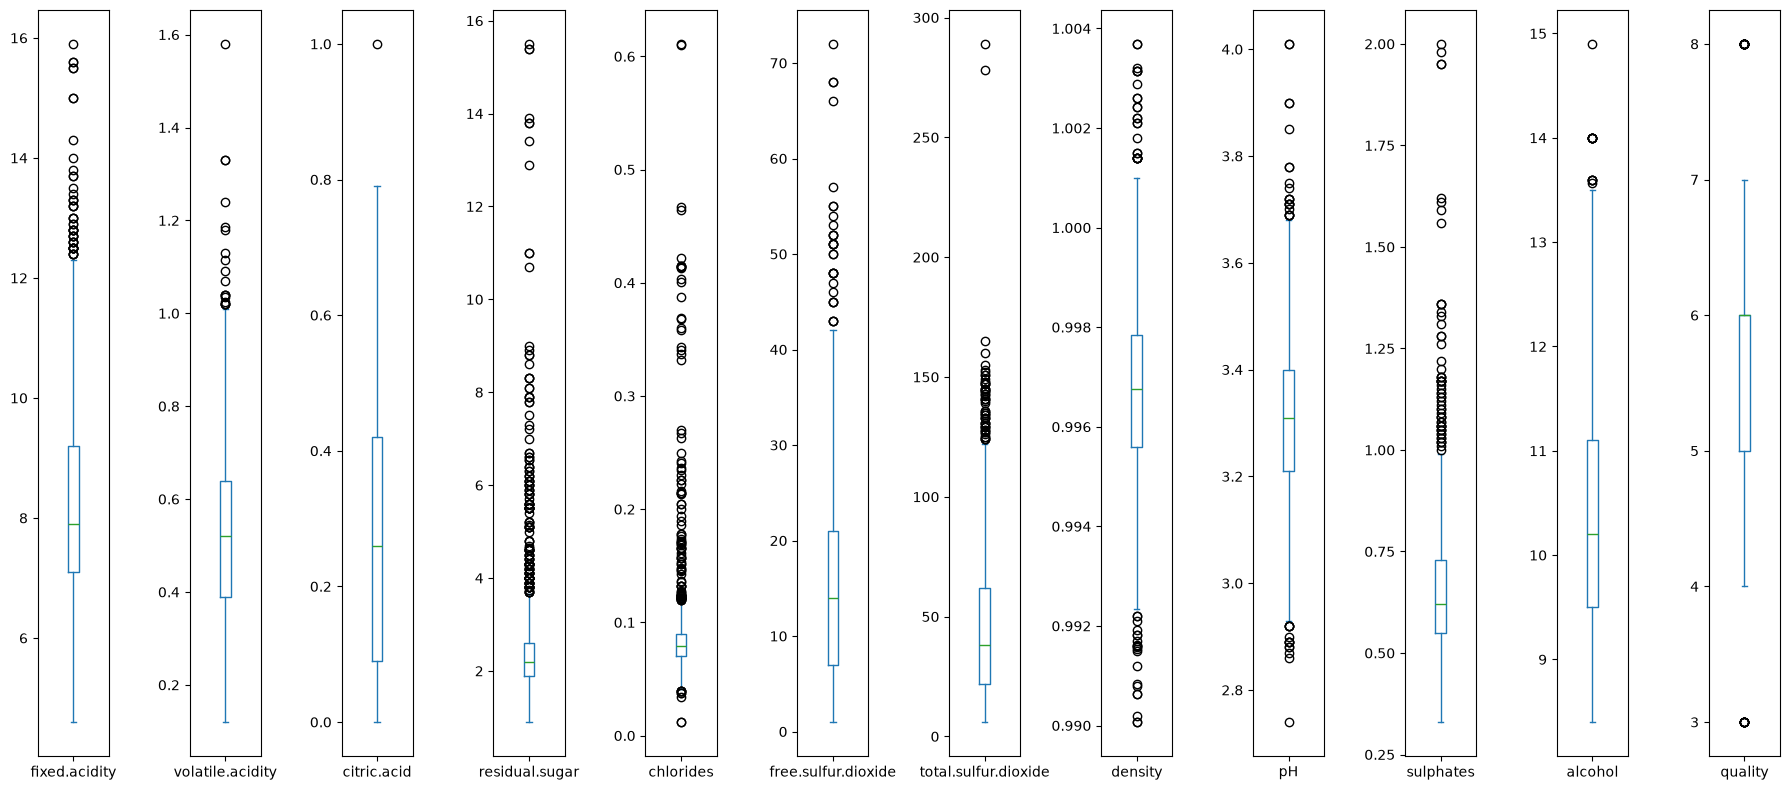

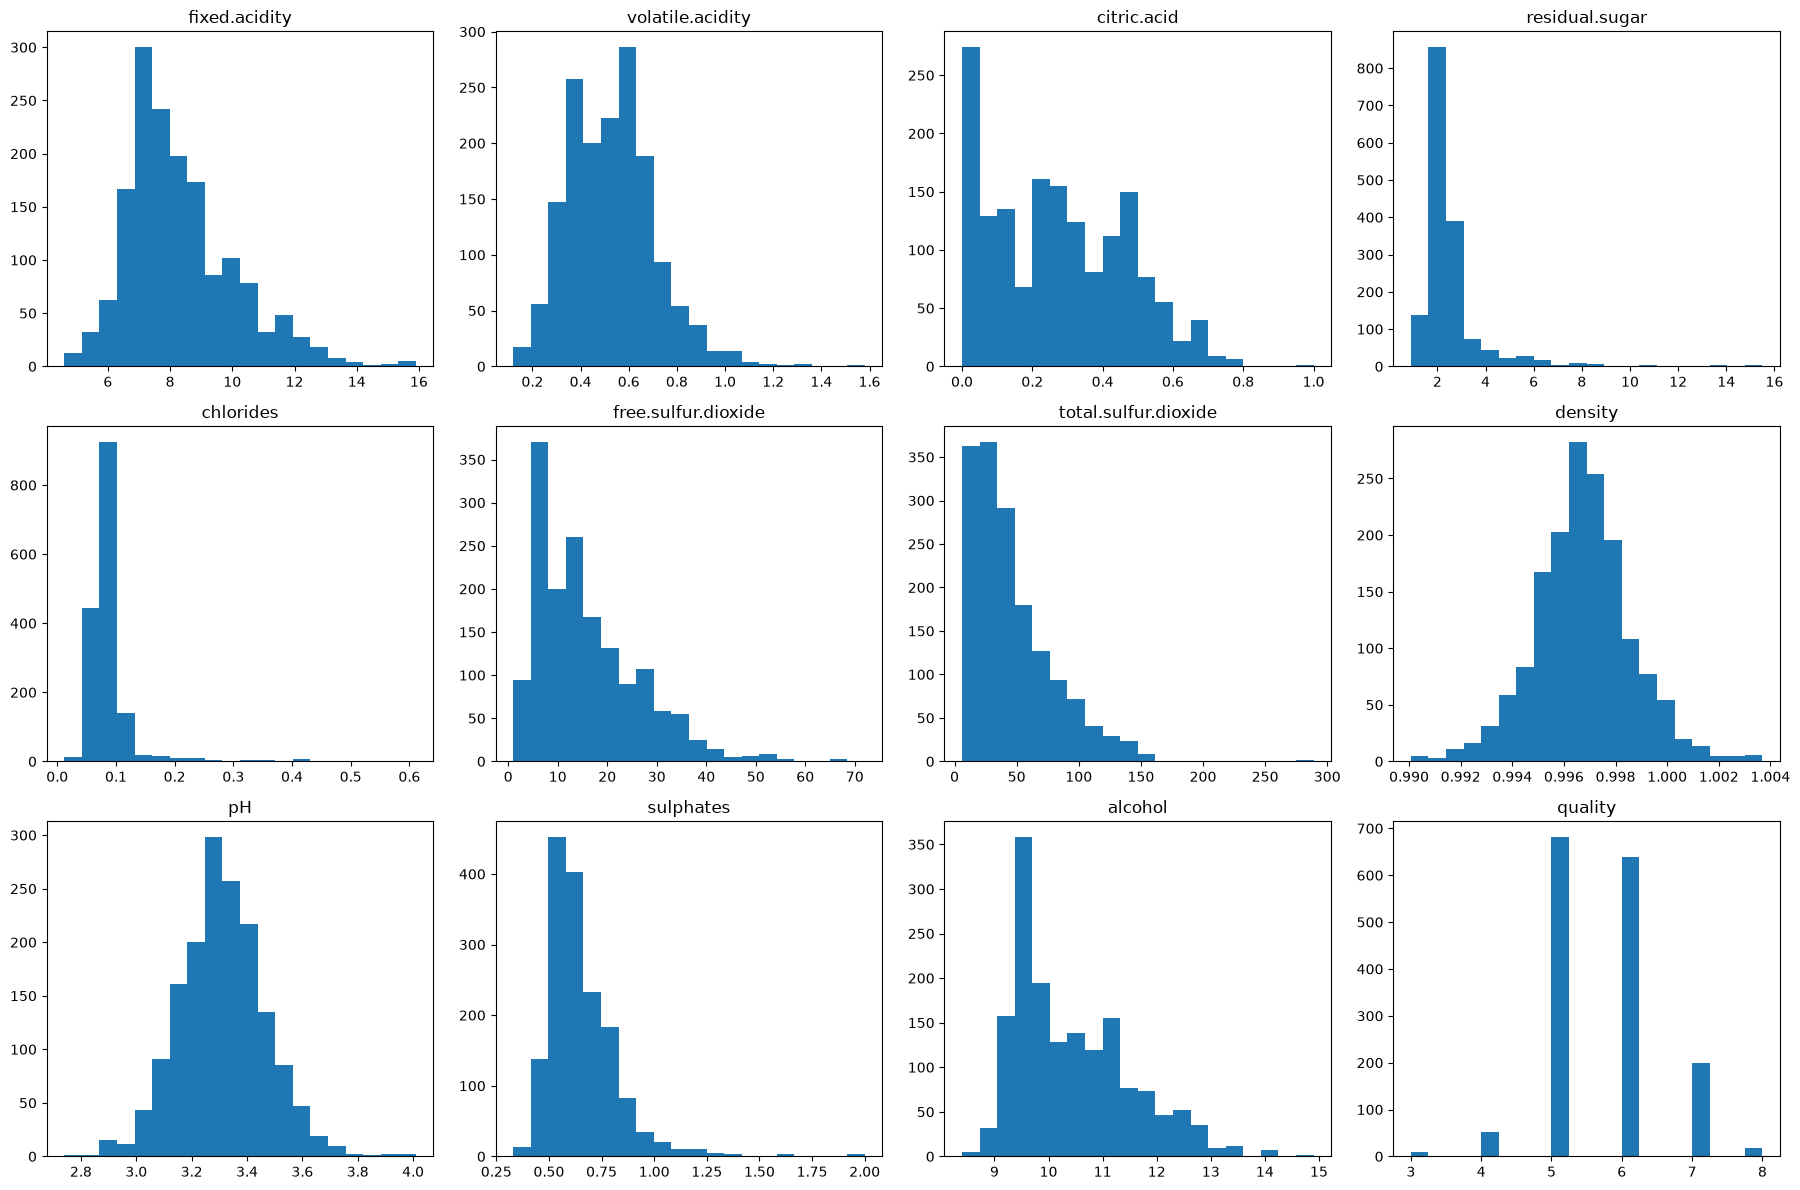

In [3]:
features = ['fixed.acidity', 'volatile.acidity', 'citric.acid', 'residual.sugar', 'chlorides', 
            'free.sulfur.dioxide', 'total.sulfur.dioxide', 'density', 'pH', 'sulphates', 'alcohol']
response = 'quality'

#boxplots
wineQuality[features+[response]].plot(kind='box', subplots=True, figsize=(18, 8))
plt.tight_layout()
plt.show()

#histograms
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(features + [response]):
    axes[i].hist(wineQuality[col], bins=20)
    axes[i].set_title(col)
for j in range(len(features + [response]), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [4]:
#Distribution of observations for quality
wineQuality[response].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

## Multivariable Analysis
There does seem to be a linear relationship between many of the features (via pairplot and heatmap), so there may be some multicollinearity that should be addressed before modeling. Some notable examples are `pH` and `fixed.acidity` as well as `citric.acid` and `volatile.acidity`, which makes sense because pH itself is a measurement for acidity. 

From the violin plots, there is a consistent trend for many of the features, such as in the cases of `alcohol`, `sulphates`, and `citric.acid` which trend up, as well as `volatile.acidity` and `density` which trend down as quality increases. However, the distributions of classes overlap considerably. There is also a class imbalance which may affect the distributions significantly. 

The permutation tests show that for most of the variables (excluding `residual.sugar`), the p-values are below 0.05, meaning that the observed relationships are unlikely to have been observed by chance, so there is some association between these features and the target variable

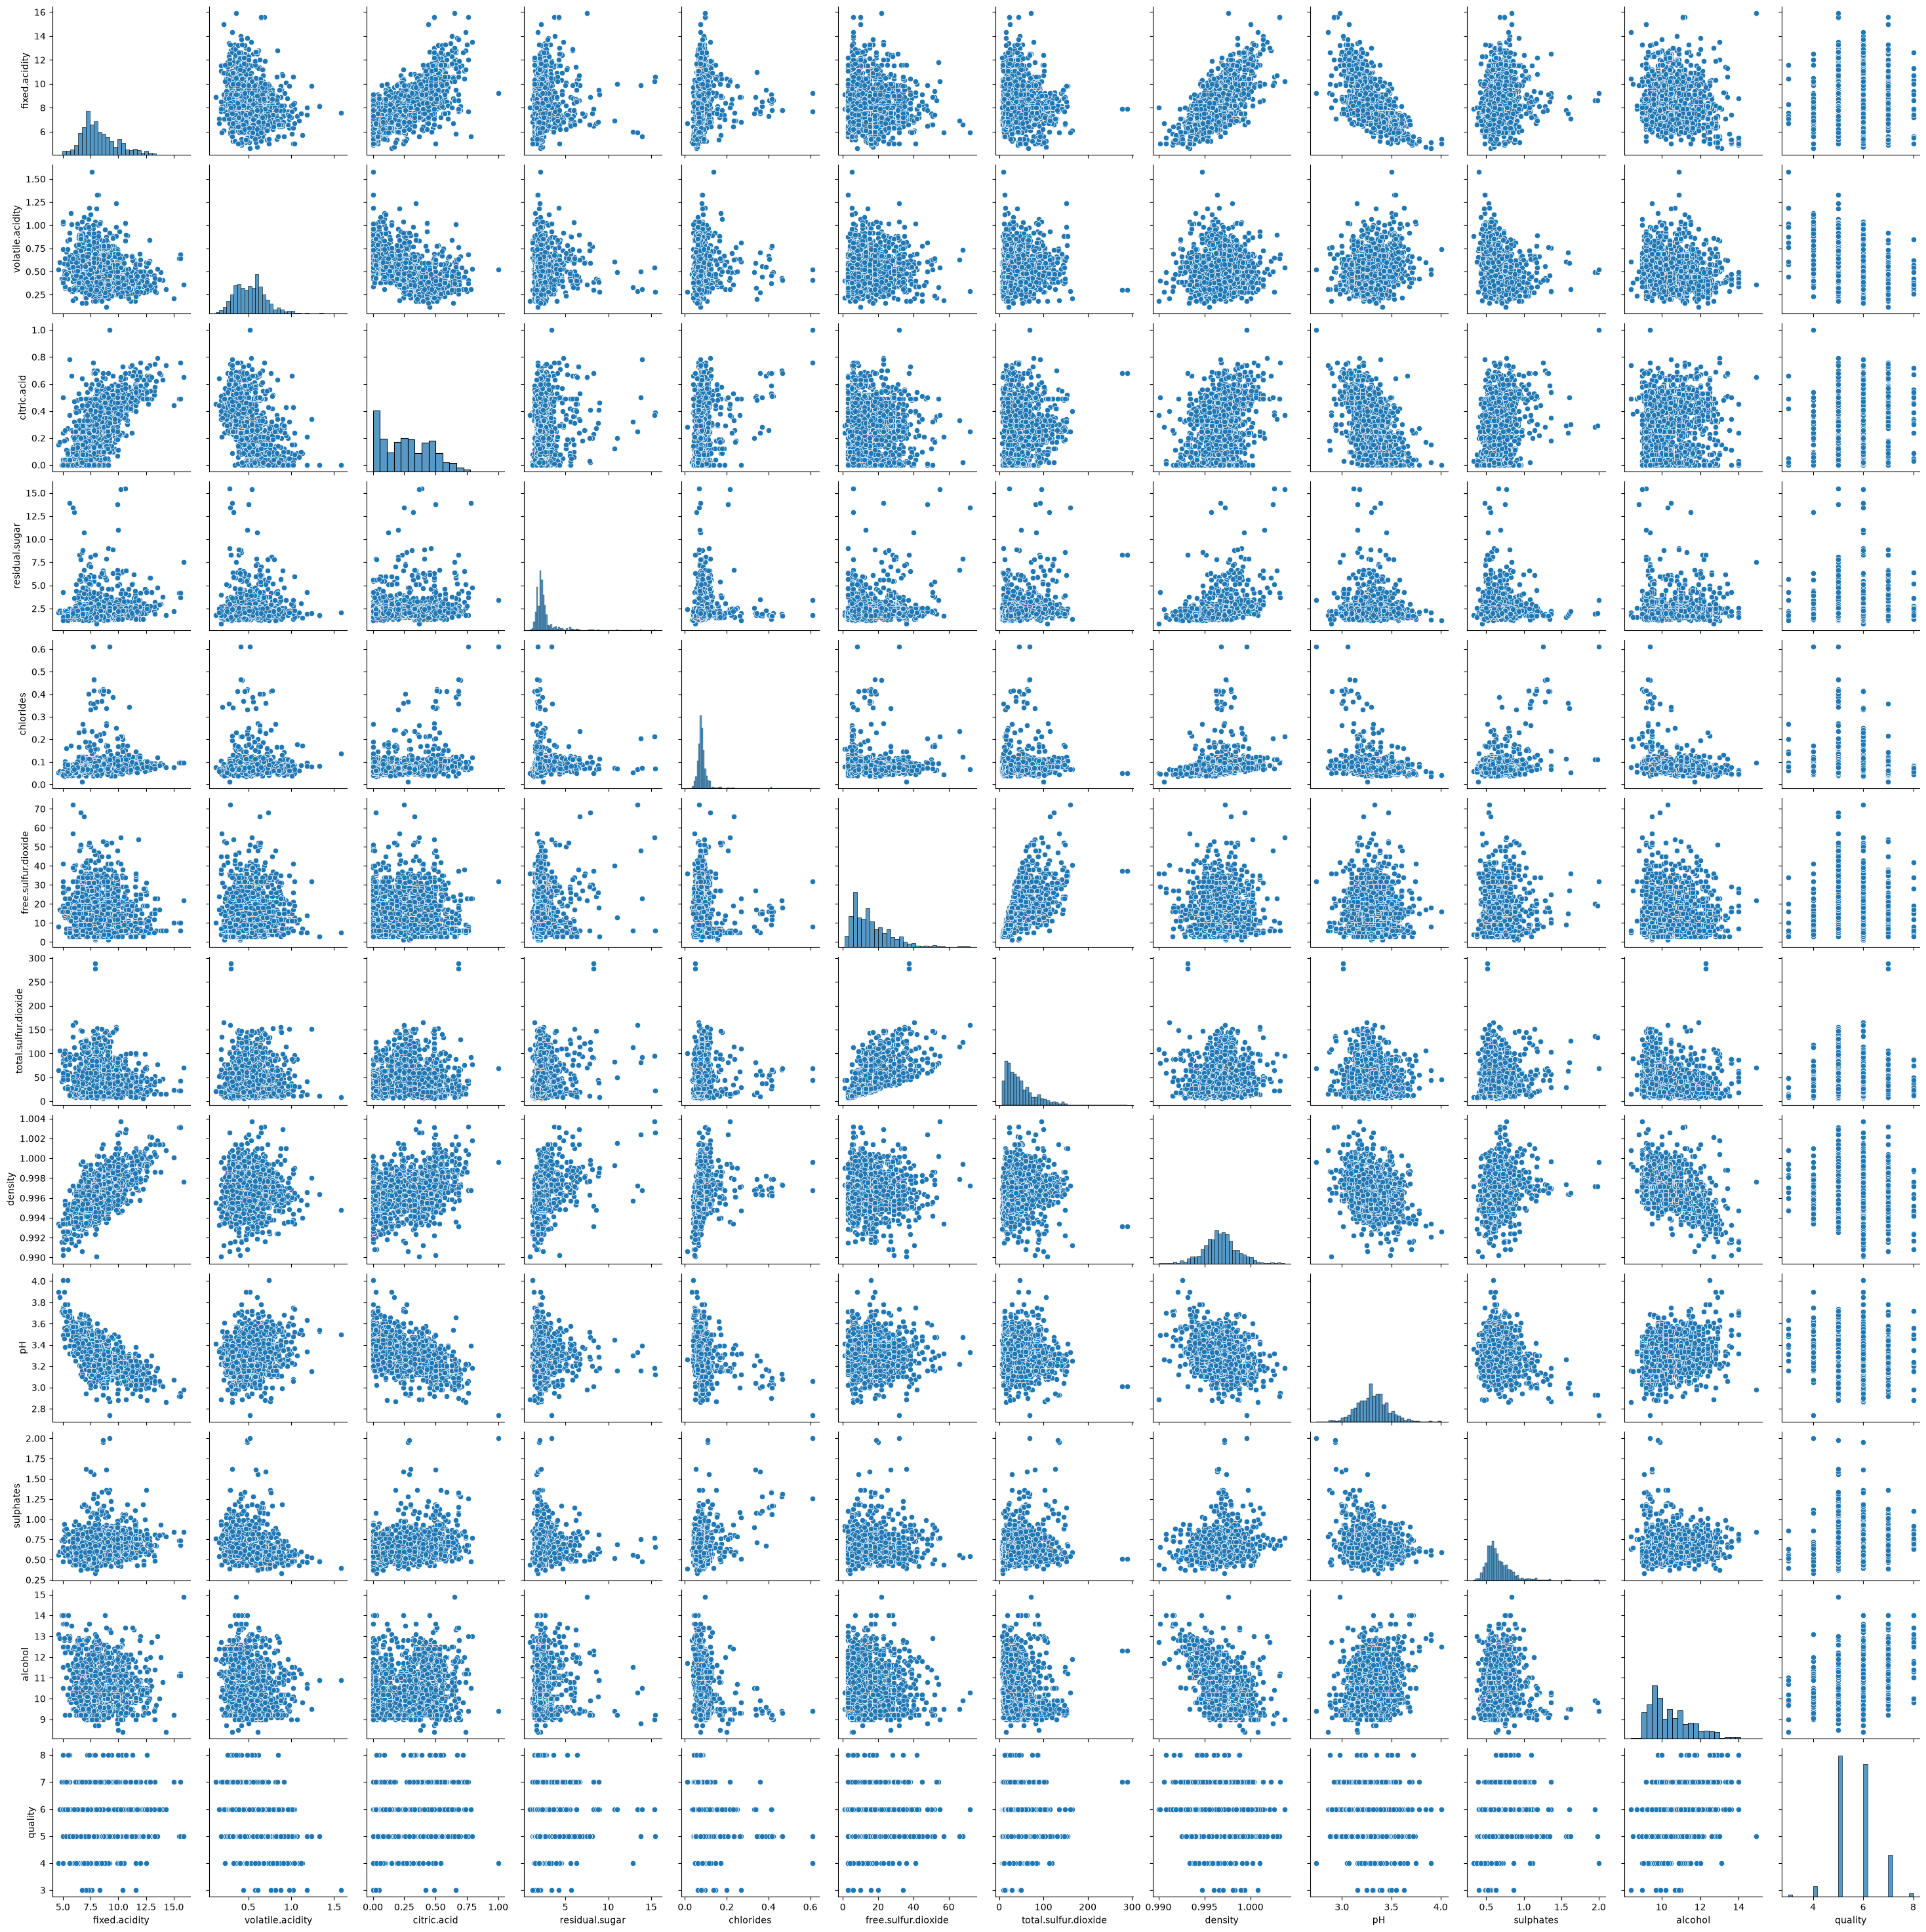

In [5]:
#pairplot for all features
sns.pairplot(wineQuality)

<Axes: >

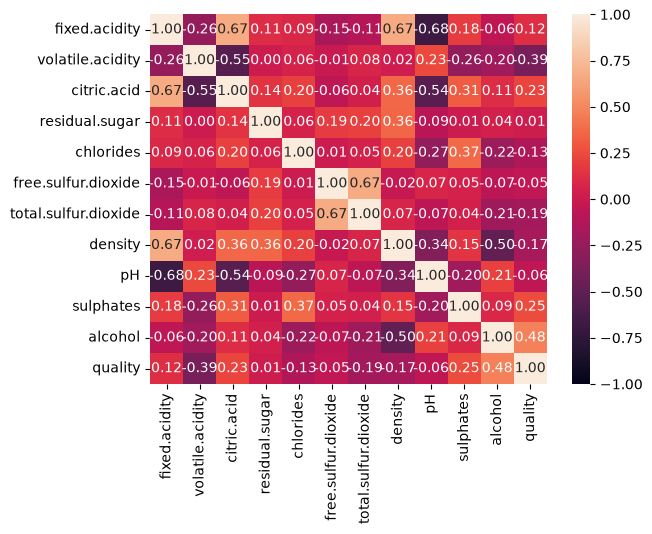

In [6]:
#heat map of correlations between all variables in wine dataset
correlations_wine = wineQuality.corr()
sns.heatmap(correlations_wine, annot=True, vmin=-1, vmax=1, fmt=".2f")

In [7]:
#permutation test for all features with quality
def permutationTest(x, y, num_permutations):
    x = np.asarray(x)
    y = np.asarray(y)
    observed_statistic = np.corrcoef(x, y)[0, 1]

    y_shuffled = y.copy()
    permuted_statistics = np.empty(num_permutations)
    for i in range(num_permutations):
        np.random.shuffle(y_shuffled)
        permuted_statistics[i] = np.corrcoef(x, y_shuffled)[0, 1]

    p_value = (np.sum(np.abs(permuted_statistics) >= np.abs(observed_statistic)) + 1) / (num_permutations + 1)
    return p_value

In [8]:
for f in features:
    curr_p_val = permutationTest(wineQuality[f], wineQuality[response], 1000)
    print(f"The p-value between {f} and {response} is {curr_p_val}")

The p-value between fixed.acidity and quality is 0.000999000999000999
The p-value between volatile.acidity and quality is 0.000999000999000999
The p-value between citric.acid and quality is 0.000999000999000999
The p-value between residual.sugar and quality is 0.5954045954045954
The p-value between chlorides and quality is 0.000999000999000999
The p-value between free.sulfur.dioxide and quality is 0.04195804195804196
The p-value between total.sulfur.dioxide and quality is 0.000999000999000999
The p-value between density and quality is 0.000999000999000999
The p-value between pH and quality is 0.01898101898101898
The p-value between sulphates and quality is 0.000999000999000999
The p-value between alcohol and quality is 0.000999000999000999


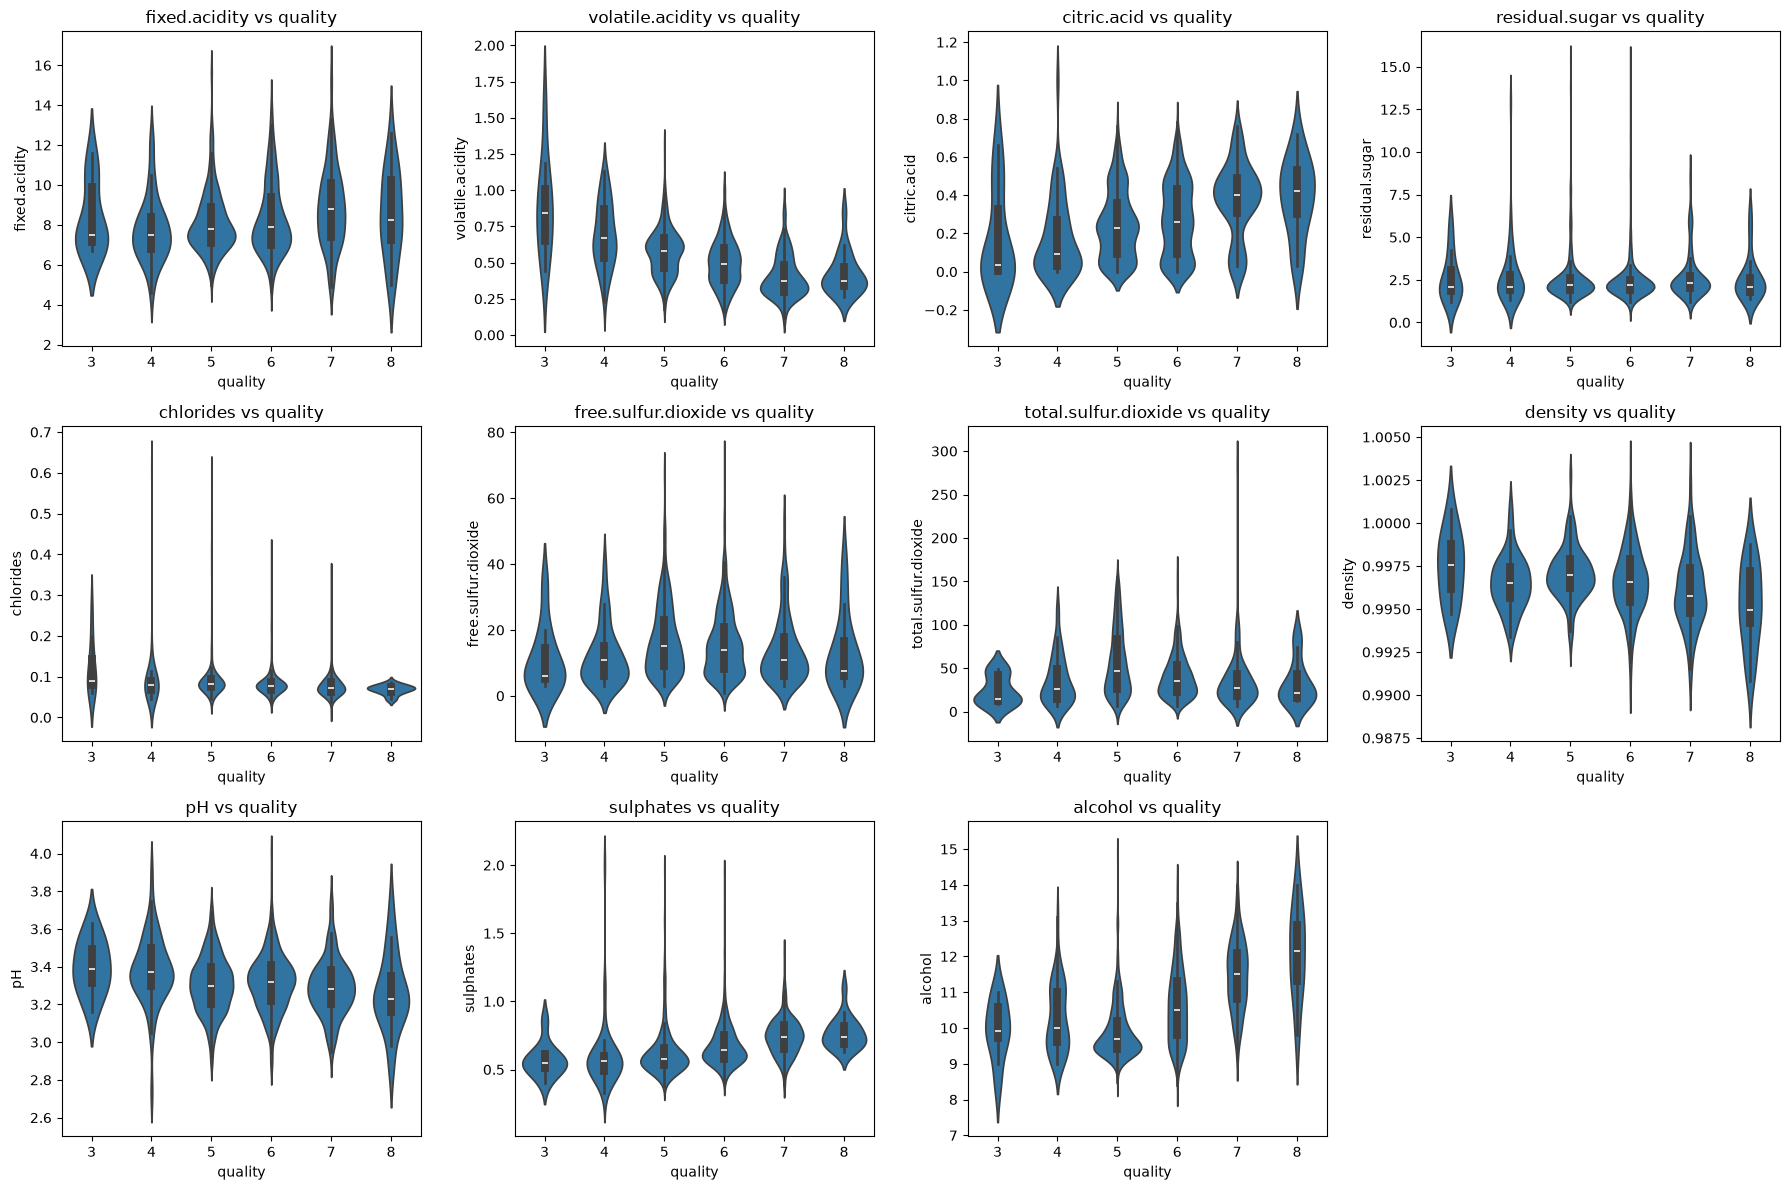

In [9]:
#violin plots of the features vs quantity
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, f in enumerate(features):
    sns.violinplot(data=wineQuality, x=response, y=f, ax=axes[i])
    axes[i].set_title(f"{f} vs {response}")

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Modeling

In [10]:
#train test splitting - 25% test
from sklearn.model_selection import train_test_split
X=wineQuality.drop(response, axis=1)
y=wineQuality[response]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Regression models
The benefit of regression is less disrupted by class imbalance class imbalance compared to classification by it's ability to predict a general trend, since it predicts a continuous number. Since `quality` is ordinal, regression is appropriate as it naturally respects ordering and will treat predicting 3 vs 4 as having a lower error compared to 3 vs 7, unlike classification which will treat it the same.

The first model chosen was Random Forest Regressor. This model is robust for large amounts of outliers and heavily skewed data, and it can capture non-linear relationships. Randomized grid search cv was used to find the optimal parameters for this model. This model scored around 0.4 for test data

The second model chosen was Multiple Linear Regression. This model was chosen for its simplicity. However this model assumes linear relationships between the features and target variable, as well as normally distributed data that is free of outlier, which is not the case for this data. Since multicollinearity was present, the variance inflation factor (VIF) was calculated for all features, and features were removed iteratively until the remaining set had a 
VIF below ~5. Both OLS and Ridge regression were tested, however both similarly underperformed compared to random forest regressor, each recieving scores of . This suggests that the relationship between the features and target variable is non-linear

Fitting 5 folds for each of 25 candidates, totalling 125 fits
test:
Mean Absolute Error (MAE): 0.43289422170711234
Median absolute error : 0.33640277777777694
R-squared Score: 0.48282698626790066

training:
Mean Absolute Error (MAE): 0.19831257019669238
Median absolute error: 0.12833333333333297
R-squared Score: 0.8763108972960187


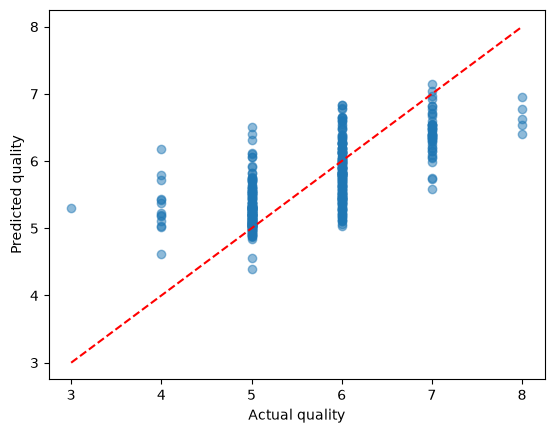

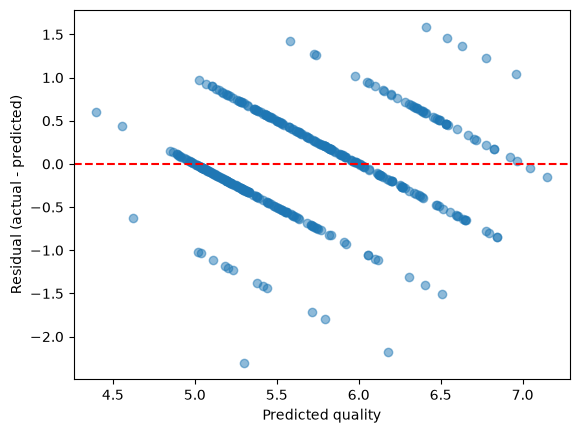

In [11]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV


rlf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

#Finding optimal parameters
rscv = RandomizedSearchCV(
    estimator=rlf,
    param_distributions=param_grid,
    n_iter=25,              # only try 25 combos instead of 243
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1,
    verbose=1,
    random_state=42
)

#fitting model and getting predictions for random forest regressor
rscv.fit(X_train, y_train)
best_model = rscv.best_estimator_
y_pred = best_model.predict(X_test)

#test scores
mae = mean_absolute_error(y_test, y_pred)
mdae = median_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#training scores
y_pred_train = best_model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mdae = median_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print("test:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Median absolute error : {mdae}")
print(f"R-squared Score: {r2}")
print("\ntraining:")
print(f"Mean Absolute Error (MAE): {train_mae}")
print(f"Median absolute error: {train_mdae}")
print(f"R-squared Score: {train_r2}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual quality')
plt.ylabel('Predicted quality')
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted quality')
plt.ylabel('Residual (actual - predicted)')
plt.show()

In [12]:
#Variance Inflation Factor of all features
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = features
vif_data['VIF'] = [variance_inflation_factor(wineQuality[features].values, i) for i in range(len(features))]
vif_data

,feature,VIF
0,fixed.acidity,74.452265
1,volatile.acidity,17.060026
2,citric.acid,9.183495
3,residual.sugar,4.662992
4,chlorides,6.554877
5,free.sulfur.dioxide,6.442682
6,total.sulfur.dioxide,6.519699
7,density,1479.287209
8,pH,1070.967685
9,sulphates,21.590621


In [13]:
#using VIF to pick features for model to prevent multicollinearity
X = wineQuality.copy()
X = X.drop(columns=['quality', 'density', 'pH'])
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                feature        VIF
0         fixed.acidity  37.557809
8               alcohol  37.137148
7             sulphates  21.218142
1      volatile.acidity  15.651760
2           citric.acid   8.636667
5   free.sulfur.dioxide   6.357695
6  total.sulfur.dioxide   5.987189
4             chlorides   5.935002
3        residual.sugar   4.660704


In [14]:
#Multiple linear regression (OLS and Ridge)
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error

#train test split 25% test
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.25, random_state=42)

#fitting OLS and ridge models
ols = LinearRegression().fit(X_train_lr, y_train_lr)
ridge = Ridge(alpha=1.0).fit(X_train_lr, y_train_lr)

#predict OLS and Ridge
y_pred_ols = ols.predict(X_test_lr)
y_pred_ridge = ridge.predict(X_test_lr)

#Scores
for name, y_pred in [('OLS', y_pred_ols), ('Ridge', y_pred_ridge)]:
    mae = mean_absolute_error(y_test_lr, y_pred)
    r2 = r2_score(y_test_lr, y_pred)
    print(f"{name}: MAE={mae:.4f}, R²={r2:.4f}")

print("Train R²:", r2_score(y_train_lr, ols.predict(X_train_lr)))
print("Test R²:", r2_score(y_test_lr, ols.predict(X_test_lr)))
print("Train R²:", r2_score(y_train_lr, ridge.predict(X_train_lr)))
print("Test R²:", r2_score(y_test_lr, ridge.predict(X_test_lr)))


OLS: MAE=0.5011, R²=0.3645
Ridge: MAE=0.5031, R²=0.3618
Train R²: 0.35166383579612326
Test R²: 0.3645385705929941
Train R²: 0.35094118844208055
Test R²: 0.3617706932246


### Classification Models
Classification models treat each class as a separate entity. This means that classification will treat a difference between 3 and 4 to be the same as between 3 and 8, which may limit models for this data. Classification models can also provide probability estimates for each class, which regression models do not produce directly. The output predictions do not need to be rounded as they are in regression (regression outputs continuous numbers).

The first model chosen was K Nearest Neighbor Classifier. KNN Classifier relies on distance proximity. For this model, the number of nearest neighbors was chosen  by iterating through the range of 1 and 32 and picking the value with the best cross validation score. The model was weighted based on distance to make it less sensitive to outliers and skew. Standard Scaler was used to standardize the data. The benefits of KNN Classifier are that it is simple and works well with small data sets. However, a disadvantage is that it is sensitive to irrelevant features which may harm this model for this data. This model performed well, receiving an ROC-AUC score of around 0.73. The model seemed to underperform the most with class 3, which contains the least amount of data points, most of which are considered outliers. The model had an ROC-AUC score of ~0.49 for class 3.

The next model chosen was Random Forest Classifier. Random Forest Classifier relies on decision trees. The class weight parameter was set to balanced to allow for misclassifications of the minority class to be penalized. The benefit of Random Forest Classifier is that it is robust to outliers and non-parametric (this dataset has very skewed features and a large amount of outliers). Random Forest also calculates a feature's importance by taking into account the relative contributions of each feature to the overall impurity reduction of all the trees in the forest. The disadvantages of using Random Forest Classifier are that the model can take up a lot of memory and computing power. It is also difficult to understand the logic behind each prediction (black box models) and it can suffer from overfitting. This model performed slightly better compared to the KNN Classifier, achieving an ROC-AUC score of ~0.77. However, on a per-class basis, Random Forest performed worse than KNN specifically on class 3 (AUC ~0.37 vs. ~0.49). Random Forest Classifier did however score higher on class 8 compared to KNN (0.83 vs. 0.71). One thing to note, is the number of samples for classes 3 and 8 are very low (1 and 5 samples respectively), so these per-class AUC scores are highly sensitive to individual 
predictions and should not be treated as statistically reliable comparisons between the models.

Best k: 29, AUC: 0.7593
ROC AUC Score: 0.7638


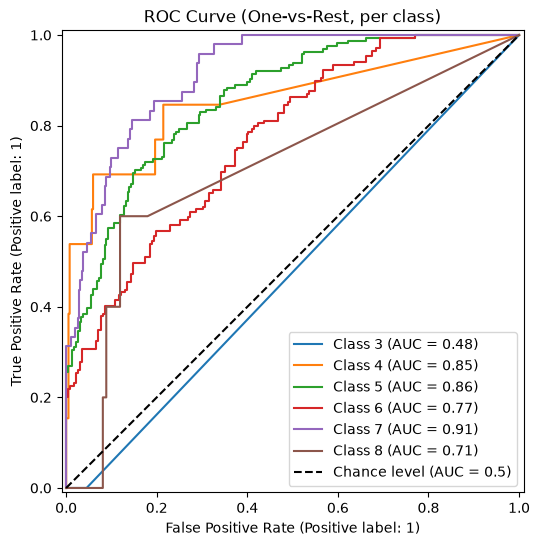

In [15]:
#K Nearest Neighbor Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()

#Scaling inputs
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#iterating through values for nearest neighbors to find the one with the best cross val score
k_values = range(1, 31, 2)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_train_scale, y_train, cv=5, scoring='roc_auc_ovr')
    cv_scores.append(scores.mean())

#fits model with the best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}, AUC: {max(cv_scores):.4f}")
neigh = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
neigh.fit(X_train_scale, y_train)

#scores
y_probs = neigh.predict_proba(X_test_scale)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr')
print(f"ROC AUC Score: {auc_score:.4f}")

#Graphs
classes = neigh.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_probs[:, i],
        name=f"Class {cls}", ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.title("ROC Curve (One-vs-Rest, per class)")
plt.legend()
plt.show()

ROC AUC Score: 0.7829


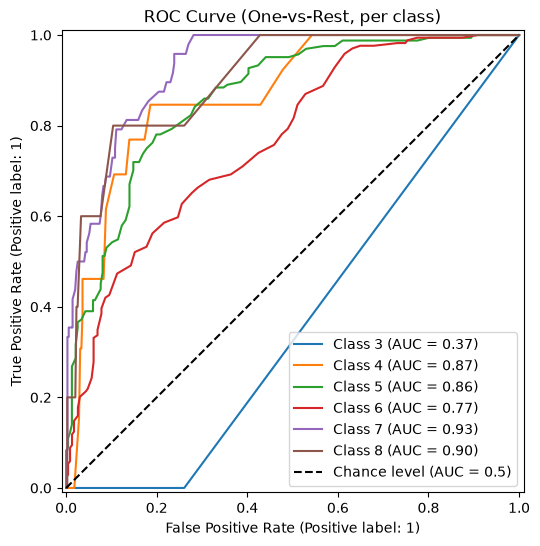

In [16]:
#Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score

#fits random forest classifier model
rf = RandomForestClassifier(random_state=42, class_weight = 'balanced')
rf.fit(X_train, y_train)

#scores
y_probs = rf.predict_proba(X_test)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr')
print(f"ROC AUC Score: {auc_score:.4f}")

#Graphs
classes = rf.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_probs[:, i],
        name=f"Class {cls}", ax=ax
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.title("ROC Curve (One-vs-Rest, per class)")
plt.legend()
plt.show()

## Results
To compare Classification and Regression models, the mean absolute error for all the models were calculated without rounding. When comparing MAE, the regression models scored the worse, with the highest being Random Forest Regressor at ~0.73. The worst classification model was KNN Classifier with a score of ~0.385. Random Forest Classifier scored the best with an MAE of ~0.38. When rounding the predictions and using accuracy, the results were the same, with Random Forest Classifier having the highest accuracy score of ~0.66. All the regressor models scored much worse compared to the classification models, with the highest regressor model being OLS with a score of ~0.59 and the lowest being Random Forest Regressor with a score of ~0.42. When calculating F1 scores for the classification models, it seems that Random Forest Classifier received higher or equal F1 scores for each class and higher overall accuracy compared to KNN, meaning that it generally performed better. 

Random Forest Classifier having a strong performance relative to Random Forest Regressor is notable, as the two both use the same algorithm. This suggests that treating `quality` as distinct classification targets, meaning allowing the model to learn independent decision boundaries, was more effecting than the continous predictions produced by regression. This is despite the expectation of Regression being able to handle the ordinality structure of `quality`. 

It is important to note that majority of the data lies within the range of 5 and 6, so the accuracy of all the models is heavily weighted towards these classes. All the models especially struggled to predict classes 3 and 8 due to the small amount of observations (all models had an f1 score of 0.0 for class 3). This means the reported accuracy largely reflects performance on the majority classes rather than balanced performance across the full quality range.

In [17]:
#MAE values for models
y_pred_knn = neigh.predict(X_test) 
y_pred_rf_clf = rf.predict(X_test)
y_pred_rf_reg = best_model.predict(X_test)  
y_pred_ols = ols.predict(X_test_lr)       
y_pred_ridge = ridge.predict(X_test_lr)     

results = {
    'KNN Classifier': mean_absolute_error(y_test, y_pred_knn),
    'Random Forest Classifier': mean_absolute_error(y_test, y_pred_rf_clf),
    'Random Forest Regressor': mean_absolute_error(y_test, y_pred_rf_reg),
    'OLS Regression': mean_absolute_error(y_test_lr, y_pred_ols),
    'Ridge Regression': mean_absolute_error(y_test_lr, y_pred_ridge),
}

for model, mae in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model}: MAE = {mae:.4f}")

Random Forest Classifier: MAE = 0.3775
Random Forest Regressor: MAE = 0.4329
OLS Regression: MAE = 0.5011
Ridge Regression: MAE = 0.5031
KNN Classifier: MAE = 0.7350


/opt/miniconda3/envs/ml_project_summer1/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


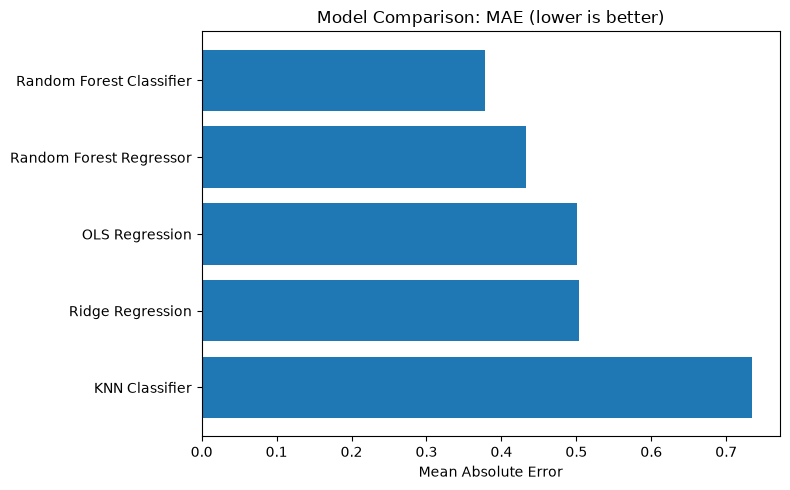

In [18]:
#Graph of MAE models
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': list(results.values())
}).sort_values('MAE')
plt.figure(figsize=(8, 5))
plt.barh(summary_df['Model'], summary_df['MAE'])
plt.xlabel('Mean Absolute Error')
plt.title('Model Comparison: MAE (lower is better)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
#accuracy score for all models
from sklearn.metrics import accuracy_score
y_pred_rf_reg_rounded = y_pred_rf_reg.round().astype(int)
y_pred_ols_rounded = y_pred_ols.round().astype(int)
y_pred_ridge_rounded = y_pred_ridge.round().astype(int)

accuracy_results = {
    'KNN Classifier': accuracy_score(y_test, y_pred_knn),
    'Random Forest Classifier': accuracy_score(y_test, y_pred_rf_clf),
    'Random Forest Regressor (rounded)': accuracy_score(y_test, y_pred_rf_reg_rounded),
    'OLS (rounded)': accuracy_score(y_test, y_pred_ols_rounded),
    'Ridge (rounded)': accuracy_score(y_test, y_pred_ridge_rounded),
}

for model, acc in sorted(accuracy_results.items(), key=lambda x: -x[1]):
    print(f"{model}: Accuracy = {acc:.4f}")

Random Forest Classifier: Accuracy = 0.6575
Random Forest Regressor (rounded): Accuracy = 0.6325
OLS (rounded): Accuracy = 0.5875
Ridge (rounded): Accuracy = 0.5850
KNN Classifier: Accuracy = 0.4100


In [20]:
#Classification report of KNN and Random Forest
from sklearn.metrics import classification_report

for name, preds in [('KNN', y_pred_knn), ('RF Classifier', y_pred_rf_clf),
                     ('RF Regressor', y_pred_rf_reg_rounded)]:
    print(f"\n{name}:")
    print(classification_report(y_test, preds, zero_division=0))


KNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        13
           5       0.41      0.99      0.58       164
           6       0.00      0.00      0.00       169
           7       0.29      0.04      0.07        48
           8       0.00      0.00      0.00         5

    accuracy                           0.41       400
   macro avg       0.12      0.17      0.11       400
weighted avg       0.20      0.41      0.25       400


RF Classifier:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.27      0.31      0.29        13
           5       0.76      0.73      0.74       164
           6       0.69      0.61      0.65       169
           7       0.48      0.77      0.59        48
           8       0.00      0.00      0.00         5

    accuracy                           0.66       400
 

## Conclusion
The results are in line with the hypothesis. Classification models generally outperform regression models. This is likely due to independent modeling of each class in `quality` which resulted in more effective class boundaries than a single continuous prediction function could achieve.

This project highlighted that class imbalance was an issue that affected both types of models. Class 3 was consistently unlearnable by both classification models and greatly affected the regression models. This is due to there being too few observations for the models to learn from or evaluate reliably.

Future work could address this issue in a few ways. One way would be to collect more data for the underrepresented quality classes. However, this may be difficult and require time and funds. Another way would be to combine classes together (3 with 4; 8 with 9) or reframe the target to be a scoring of low, medium, high. 